## Vector Schema Design

- <b> A vector record is not just an embedding. The embedding is the searchable part; the metadata makes the retrieval system controllable, traceable, and maintainable.
</b>
- Our vector record should conceptually look like this :

<pre>
Vector Record
│
├── Identity
│   ├── vector_id
│   ├── source_record_id
│   └── chunk_id
│
├── Embedding
│   ├── embedding
│   ├── embedding_model
│   └── embedding_version
│
├── Lineage
│   ├── source_uri / source_table
│   ├── created_at
│   └── updated_at
│
├── Retrieval Metadata
│   ├── title
│   ├── document_type
│   └── language
│
├── Filtering
│   ├── tenant_id
│   ├── region
│   └── effective_date
│
├── Governance
│   ├── access_group
│   ├── sensitivity_label
│   └── compliance_region
│
├── Evaluation
│   ├── benchmark_split
│   ├── query_family
│   └── ground_truth_label
│
└── Operations
    ├── ingestion_run_id
    ├── parser_version
    ├── chunking_strategy
    └── last_source_hash
    </pre>

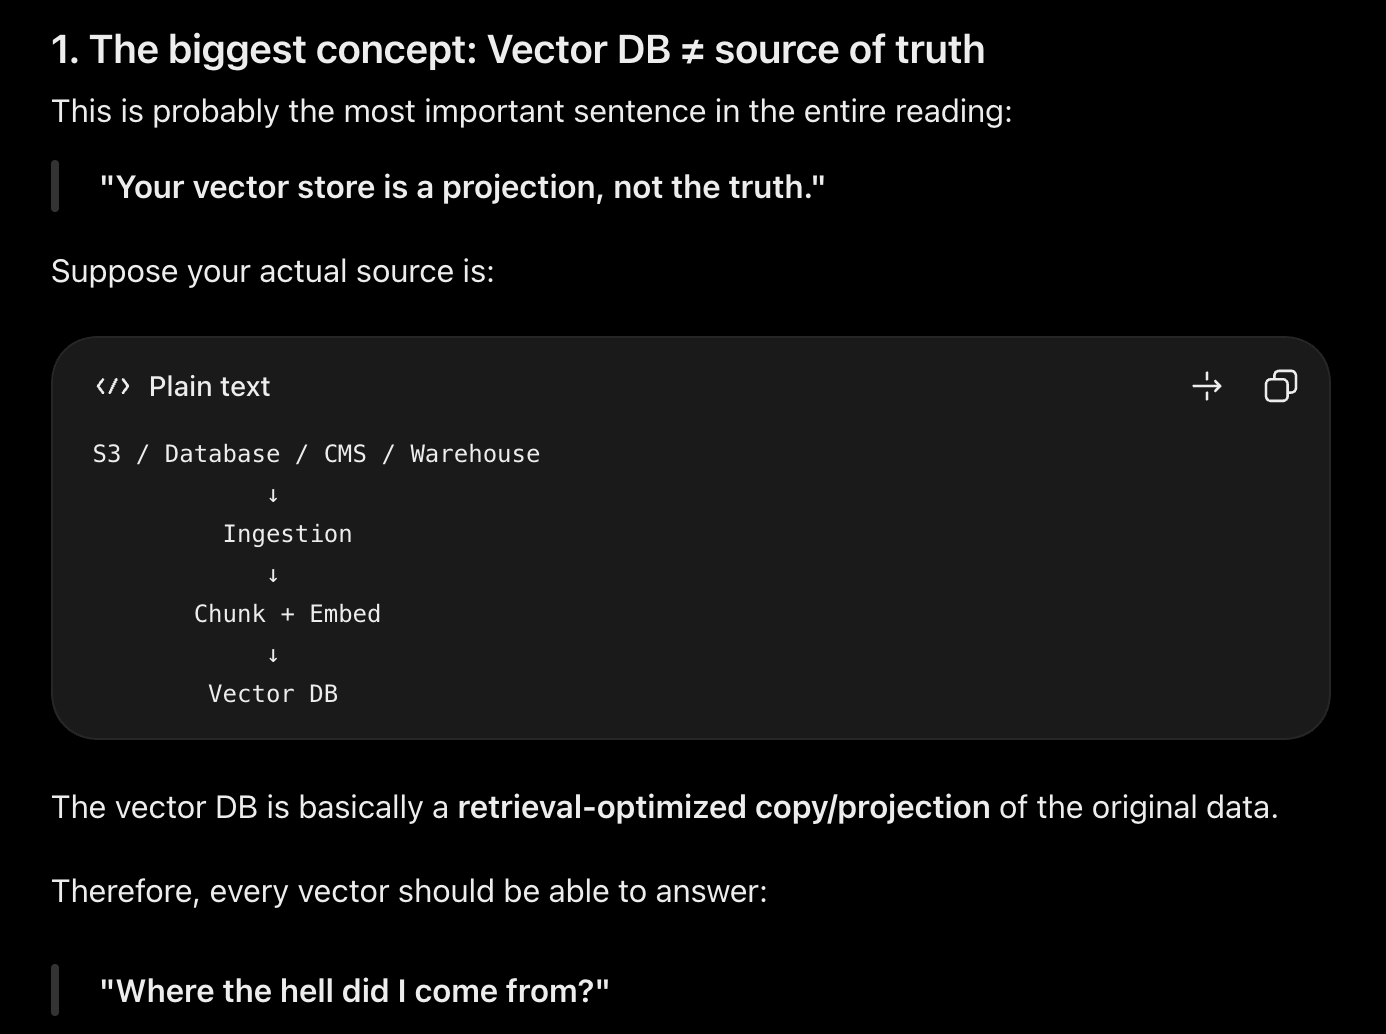

### That's what:
<pre>
source_record_id
source_uri
chunk_id
</pre>
are for.

# 2.Why vector_id and source_record_id are different
<pre>
This is worth understanding.
Imagine:
source_record_id = policy_00421

That's the original document.
But you split it into:
chunk_01
chunk_02
chunk_03
chunk_04

Each chunk becomes a vector:
vector_id = policy_00421_chunk_03_v1
source_record_id = policy_00421
chunk_id = chunk_03

So:
ONE DOCUMENT
     │
     ├── chunk 1 → vector
     ├── chunk 2 → vector
     ├── chunk 3 → vector
     └── chunk 4 → vector

source_record_id tells you which original object.
chunk_id tells you which piece.
vector_id uniquely identifies the vector record itself.

</pre>

# 3. Metadata is what makes retrieval controllable

## Metadata has total of 5 Categories 

### Descriptive

<pre>
"What is this?"

title
document_type
language
section_name
</pre>

### Filterable
<pre>
Answers:
"Which candidates should even be considered?"

tenant_id
region
effective_date
published_status
</pre>

### Governance 
<pre>Answers:
"Who is allowed to see/use this?"

access_group
sensitivity_label
compliance_region</pre>

### Evaluation
<pre>Answers:
"How do we measure retrieval?"

benchmark_split
query_family
ground_truth_label</pre>

### Operational 
<pre>Operational
Answers:
"How was this record created/updated?"

ingestion_run_id
parser_version
chunking_strategy
last_source_hash</pre>


# **The disticntion to remember**

- Don't think:
"Metadata = extra information."

- Think:
Metadata provides different control surfaces for retrieval, security, evaluation, and maintenance.


# 4. Filterable metadata is particularly important
<pre>The reading gives a very practical warning.
Suppose you have:
region = US

but another pipeline stores:
region = usa

and another:
region = United States

Now you try:
region == "US"

Your filter isn't reliably enforcing anything.
So:
Filterable metadata needs to be typed, normalized, stable, and documented.

That's important for your security architecture because if you're going to eventually enforce something like:
tenant_id == authenticated_user.tenant_id

you absolutely cannot have messy/inconsistent tenant metadata.</pre>

# 5. Governance metadata ≠ ordinary metadata
<pre> This is the part I'd highlight for your project.
Suppose:
sensitivity_label = restricted
access_group = security_team
tenant_id = company_A

Those fields aren't there to make the document easier to search.
They're there because they affect whether the document should be retrievable at all.
So the retrieval process eventually becomes:
Query
  ↓
Candidate retrieval
  ↓
Metadata eligibility
  ↓
Authorization / governance filtering
  ↓
Allowed results
  ↓
LLM

And notice something important:
The course explicitly says that if access control exists only in the source repository, the application may retrieve something and only reject it afterward.
That's worse architecturally than applying the constraints during retrieval because you've already allowed the restricted data into the retrieval pipeline.
That concept is directly relevant to the security system you're designing.</pre>

# 6. Document retrieval vs structured-record retrieval
<pre>You don't need to overthink this.
Document retrieval
Your source is something like:
PDF
Wiki page
Manual
Policy
Contract

You chunk it:
Document
 ↓
Chunks
 ↓
Embeddings

The document is the source of truth.
The chunk is merely a retrieval unit.
Structured-record retrieval
Your source might already be:
Support ticket
Product
Incident
Customer record
Database row

You might embed a summary of that record.
Here the vector points back to the business record/key.
So:
Document system:

source_uri
     ↓
PDF
     ↓
chunk
     ↓
vector


Structured system:

source_table + record key
     ↓
database row
     ↓
summary
     ↓
vector

The key idea:
 The schema should reflect what the vector represents in the real system.</pre>
 
 



# 7. One thing I especially want you to understand: chunks aren't truth
<pre>
The course says:
"Chunks are indexing artifacts, not truth-bearing records."

This is important.
Suppose:
Policy.pdf

is the actual source.
You create:
chunk_01
chunk_02
chunk_03

You shouldn't manually edit:
chunk_03

because that's not the authoritative document.
Instead:
Source document changes
        ↓
Re-ingest
        ↓
Re-chunk
        ↓
Re-embed
        ↓
New vector projection

This keeps the vector database synchronized with the source.</pre>

# 8. Versioning
<pre>
You already understood this from the previous section.
But now there's another layer.
You can have:
source version
embedding model
embedding version
pipeline version
chunking strategy

Why?
Imagine:
v1:
text-embedding-3-small

v2:
text-embedding-3-large

Even if the source document hasn't changed, your vectors might behave differently after re-embedding.
Or:
Chunking v1:
1000 tokens

Chunking v2:
heading-aware 800 tokens

Now your retrieval behavior can change even though the underlying document didn't.
So if retrieval suddenly gets worse, you need to be able to determine:
Was the source changed?
       ↓
Was chunking changed?
       ↓
Was embedding model changed?
       ↓
Was the pipeline changed?

That's why these version fields exist.</pre>

# 9. The schema mistakes you should remember
<pre>The course gives several.
❌ Missing source identifiers
You can't reliably trace or delete vectors.
❌ Metadata junk drawer
Something like:
metadata = {    "attributes": "random stuff..."}


eventually becomes impossible to govern.
❌ Treating chunks as source of truth
Chunks are derived artifacts.
❌ Missing embedding/pipeline versions
You can't explain retrieval changes.
❌ Sensitive metadata without access controls
Even metadata itself can leak information.
For example:
internal_investigation_status = active

could be sensitive even if the actual document text isn't exposed.
❌ Weakly typed filters
Dates, booleans, regions, etc. stored inconsistently make filtering unreliable.</pre>


# **What To retain from this huge section**
<pre>Vector
   +
Identity
   +
Lineage (Source Record)
   +
Version
   +
Filter metadata
   +
Governance metadata
   +
Evaluation metadata
   +
Operational metadata
</pre>

### **Important conceptual chain:**
<pre>Vector DB
    ↓
is NOT the source of truth
    ↓
it's a retrieval projection
    ↓
therefore every vector needs
a way to point back to the truth</pre>

# ***For The Security Project :***
<pre>VECTOR RECORD
                     │
        ┌────────────┼────────────┐
        ↓            ↓            ↓
    Retrieval     Governance    Lineage
        │            │            │
    similarity    access        source
    filtering     control       version
        │            │            │
        └────────────┼────────────┘
                     ↓
              Secure Retrieval</pre>

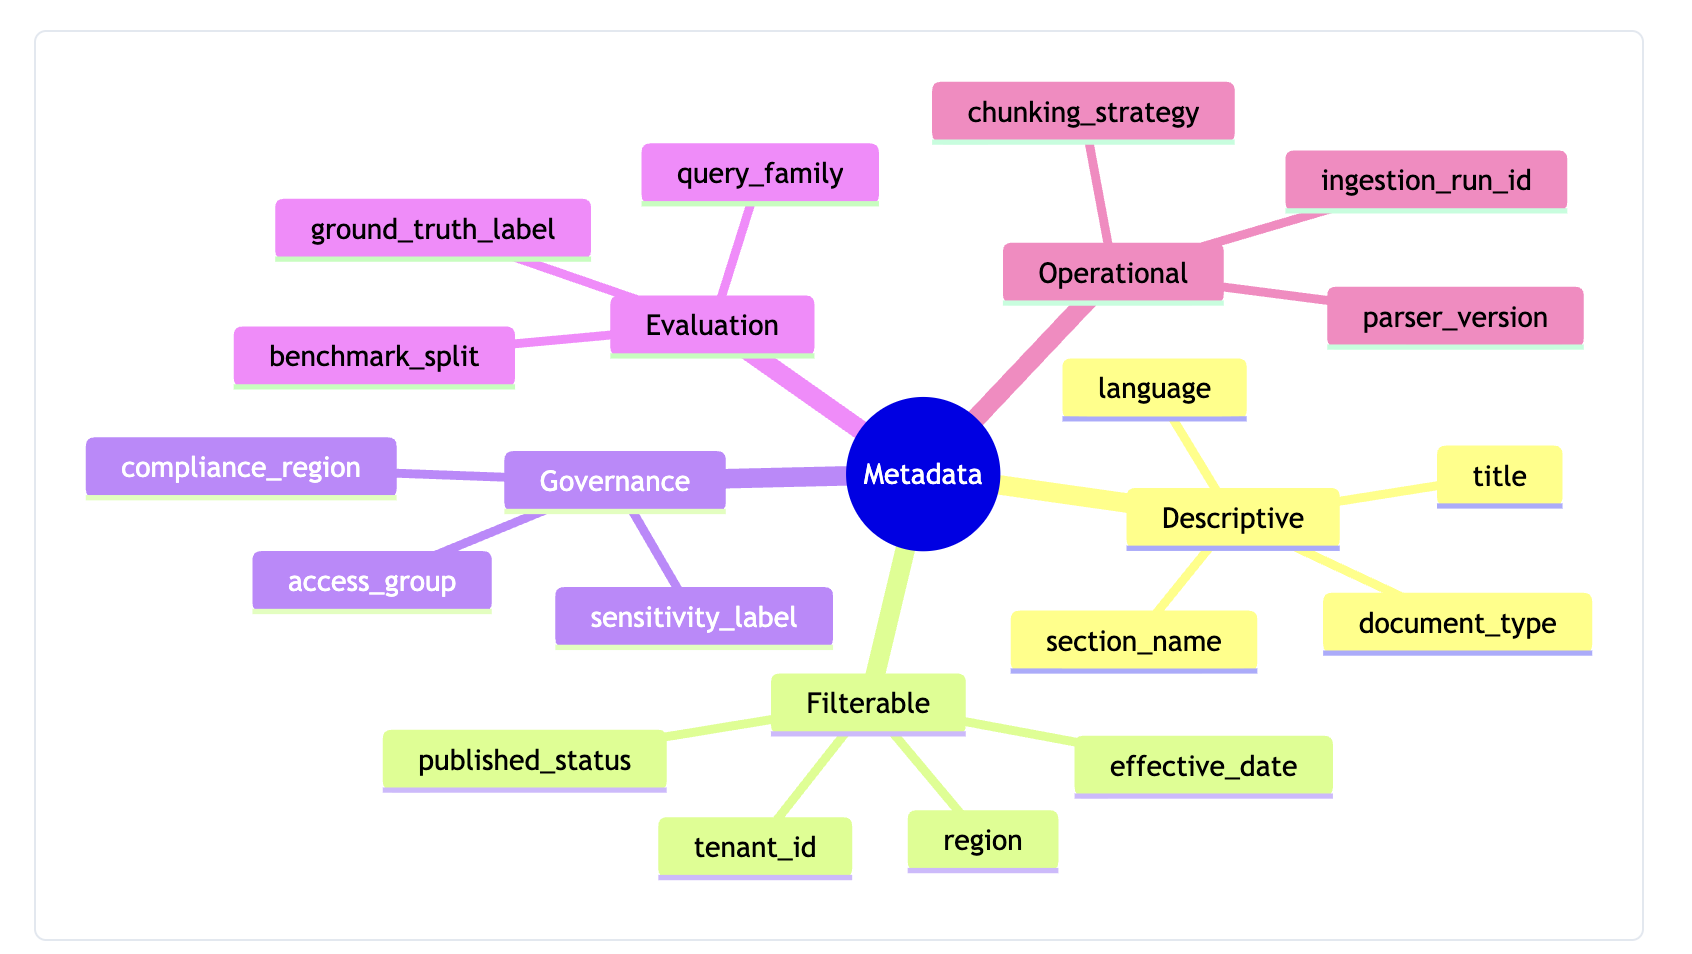